In [1]:
%load_ext autoreload
%autoreload 2

# Model Training: New Multilabel Classification Task

`Task Description: Predict the services a client will use in the next 30 days.`

In [2]:
import gc
import os
from warnings import filterwarnings

filterwarnings("ignore")
os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"

In [3]:
import torch
from relbench.datasets import get_dataset
from relbench.modeling.graph import make_pkey_fkey_graph
from relbench.modeling.utils import get_stype_proposal
from torch_frame.config.text_embedder import TextEmbedderConfig
from torch_geometric import seed_everything

In [4]:
from experiments.model_training.training.models.hgt_model import HGTModel
from experiments.model_training.training.models.sage_model import SAGEModel
from experiments.model_training.training.text_embedder import TextEmbedder
from experiments.model_training.training.trainer import Trainer
from experiments.model_training.utils import (
    get_device,
    load_config,
    make_loaders,
    patched_to_unix_time,
)

In [5]:
import relbench.modeling.graph
import relbench.modeling.utils

relbench.modeling.graph.to_unix_time = patched_to_unix_time
relbench.modeling.utils.to_unix_time = patched_to_unix_time

In [6]:
from predql_tasks.tasks import SeznamClientServisTmpTask

In [7]:
seed_everything(42)
device = get_device()
config = load_config("config.yml")
cache_dir = "./.cache_predql"
dataset_name = "ctu-seznam"
task_name = "seznam_client_servis_tmp"

Using device: cuda


In [8]:
dataset = get_dataset(dataset_name, download=False)
task = SeznamClientServisTmpTask()
db = dataset.get_db()

Loading Database object from /home/kolesiko/.cache/relbench/ctu-seznam/db...
Done in 0.12 seconds.


In [9]:
col_to_stype_dict = get_stype_proposal(db)
col_to_stype_dict

{'probehnuto_mimo_penezenku': {'__PK__': <stype.numerical: 'numerical'>,
  'client_id': <stype.numerical: 'numerical'>,
  'Month_Year': <stype.timestamp: 'timestamp'>,
  'probehla_inzerce_mimo_penezenku': <stype.categorical: 'categorical'>,
  'FK_client_client_id': <stype.numerical: 'numerical'>},
 'dobito': {'__PK__': <stype.numerical: 'numerical'>,
  'client_id': <stype.numerical: 'numerical'>,
  'month_year_datum_transakce': <stype.timestamp: 'timestamp'>,
  'sluzba': <stype.categorical: 'categorical'>,
  'kc_dobito': <stype.numerical: 'numerical'>,
  'FK_client_client_id': <stype.numerical: 'numerical'>},
 'probehnuto': {'__PK__': <stype.numerical: 'numerical'>,
  'client_id': <stype.numerical: 'numerical'>,
  'month_year_datum_transakce': <stype.timestamp: 'timestamp'>,
  'sluzba': <stype.categorical: 'categorical'>,
  'kc_proklikano': <stype.numerical: 'numerical'>,
  'FK_client_client_id': <stype.numerical: 'numerical'>},
 'client': {'__PK__': <stype.numerical: 'numerical'>,
  '

In [10]:
model_name = config["shared"]["text_embedder_model_name"]
batch_size = config["shared"]["batch_size"]

In [11]:
text_embedder = TextEmbedderConfig(
    text_embedder=TextEmbedder(
        model_name=model_name,
        device="cpu",
        cache_dir=cache_dir), batch_size=batch_size
)

data, col_stats_dict = make_pkey_fkey_graph(
    db,
    col_to_stype_dict,
    text_embedder,
    cache_dir=os.path.join(cache_dir, dataset_name)
)

data

HeteroData(
  probehnuto_mimo_penezenku={
    tf=TensorFrame([588990, 3]),
    time=[588990],
  },
  dobito={
    tf=TensorFrame([501626, 4]),
    time=[501626],
  },
  probehnuto={
    tf=TensorFrame([1321324, 4]),
    time=[1321324],
  },
  client={ tf=TensorFrame([73447, 2]) },
  (probehnuto_mimo_penezenku, f2p_FK_client_client_id, client)={ edge_index=[2, 588990] },
  (client, rev_f2p_FK_client_client_id, probehnuto_mimo_penezenku)={ edge_index=[2, 588990] },
  (dobito, f2p_FK_client_client_id, client)={ edge_index=[2, 501396] },
  (client, rev_f2p_FK_client_client_id, dobito)={ edge_index=[2, 501396] },
  (probehnuto, f2p_FK_client_client_id, client)={ edge_index=[2, 1321023] },
  (client, rev_f2p_FK_client_client_id, probehnuto)={ edge_index=[2, 1321023] }
)

In [12]:
loader_dict, mlb, _ = make_loaders(
    data,
    task,
    batch_size,
    num_neighbors=config["shared"]["num_neighbors"],
    binarize=True,
)

Loading Database object from /home/kolesiko/.cache/relbench/ctu-seznam/db...
Done in 0.08 seconds.
Loading Database object from /home/kolesiko/.cache/relbench/ctu-seznam/db...
Done in 0.08 seconds.


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

In [13]:
out_channels = len(mlb.classes_)
print(f"Number of classes: {out_channels}")

Number of classes: 8


In [14]:
task_type = task.task_type

in_channels = config["shared"]["in_channels"]
learning_rate = config["shared"]["learning_rate"]
dropout = config["shared"]["dropout"]
num_epochs = config["shared"]["num_epochs"]
num_runs = config["shared"]["num_runs"]

mlp_config = config["mlp_head"]
mlp_config["out_channels"] = out_channels

## SAGE


MODEL INFO:
Model name: SAGE
Number of parameters: 1771016


STARTING RUN 1/5


Evaluating: 100%|██████████| 282/282 [00:02<00:00, 136.77it/s]


Epoch 1/30 | Train Loss: 0.2295 | Train auprc_micro: 0.6778
Epoch 1/30 |   Val Loss: 0.2559 |   Val auprc_micro: 0.5891
New best model found with Val auprc_micro: 0.5891


Evaluating: 100%|██████████| 282/282 [00:02<00:00, 136.49it/s]


New best model found with Val auprc_micro: 0.6123


...

Evaluating: 100%|██████████| 282/282 [00:02<00:00, 105.46it/s]


!!! No improvement in Val auprc_micro for 10 epochs (Early stopping at epoch 20) !!!


Evaluating: 100%|██████████| 272/272 [00:02<00:00, 107.80it/s]


Run 5/5 | Final Train Metrics: {'auprc_macro': 0.37512918381027704, 'auprc_micro': 0.6874506773557009, 'f1_macro': 0.231428829870322, 'f1_micro': 0.47373023126899333, 'loss': 0.21741268068569514}
Run 5/5 | Final Val Metrics: {'auprc_macro': 0.3835231334048341, 'auprc_micro': 0.6198867597565242, 'f1_macro': 0.22630287177567088, 'f1_micro': 0.39352814536690744, 'loss': 0.2460210393846576}
Run 5/5 | Final Test Metrics: {'auprc_macro': 0.39030255359590105, 'auprc_micro': 0.6259773017980906, 'f1_macro': 0.22734832505041963, 'f1_micro': 0.3995571504924792, 'loss': 0.24345748584255594}
FINISHED RUN 5/5


FINAL STATS OVER 5 RUNS

[TRAIN] Metrics:
  Auprc_macro: 0.3749 ± 0.0022
  Auprc_micro: 0.6876 ± 0.0009
  F1_macro: 0.2217 ± 0.0050
  F1_micro: 0.4446 ± 0.0152
  Loss: 0.2174 ± 0.0003

[VAL] Metrics:
  Auprc_macro: 0.3858 ± 0.0029
  Auprc_micro: 0.6217 ± 0.0017
  F1_macro: 0.2172 ± 0.0046
  F1_micro: 0.3676 ± 0.0131
  Loss: 0.2437 ± 0.0012

[TEST] Metrics:
  Auprc_macro: 0.3922 ± 0.0033
  Aup

12

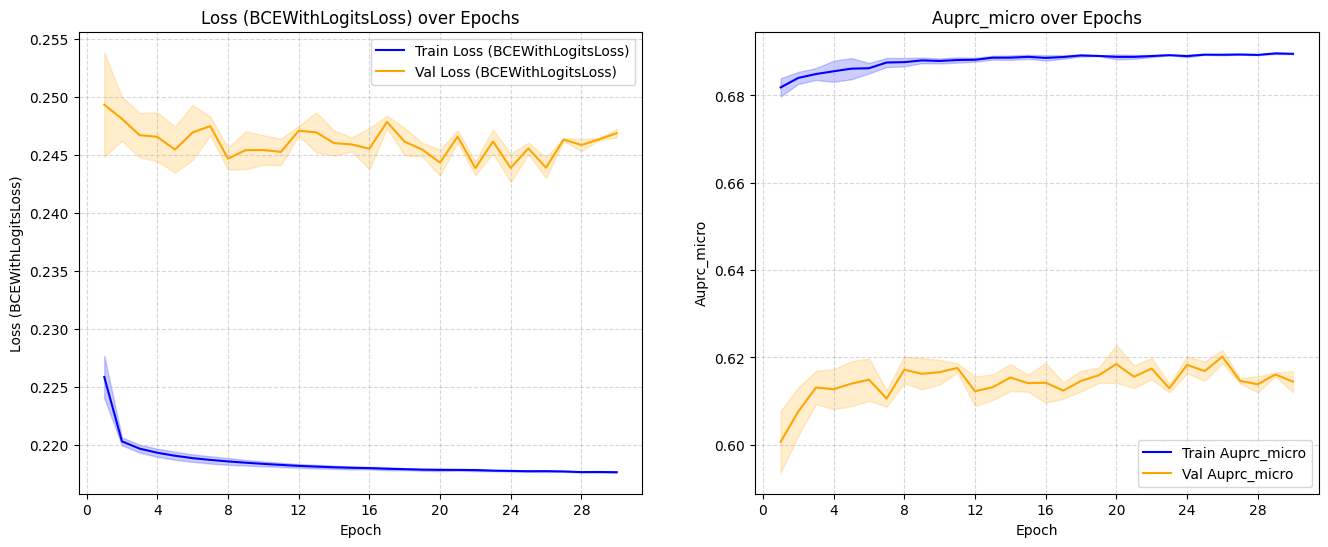

In [15]:
sage_model = SAGEModel(
    data=data,
    col_stats_dict=col_stats_dict,
    in_channels=in_channels,
    gnn_config=config["gnn_heads"]["sage"],
    mlp_config=mlp_config,
    task_type=task_type,
    dropout=dropout
).to(device)

criterion = torch.nn.BCEWithLogitsLoss()
optimizer = torch.optim.AdamW(sage_model.parameters(), lr=learning_rate)

trainer = Trainer(
    task=task,
    model=sage_model,
    optimizer=optimizer,
    criterion=criterion,
    device=device
)

trainer.run_experiment(
    loader_dict,
    num_epochs,
    tune_metric="auprc_micro",
    higher_is_better=True,
    patience=10,
    print_every=3,
    num_runs=num_runs
)

# torch.save(best_weights, os.path.join(cache_dir, dataset_name, f"{sage_model.gnn_name}_{task_name}_best_weights.pt"))

del sage_model, optimizer, trainer
torch.cuda.empty_cache()
gc.collect()

## HGT


MODEL INFO:
Model name: HGT
Number of parameters: 2266424


STARTING RUN 1/5


Evaluating: 100%|██████████| 282/282 [00:03<00:00, 93.93it/s]


Epoch 1/30 | Train Loss: 0.2413 | Train auprc_micro: 0.6554
Epoch 1/30 |   Val Loss: 0.2597 |   Val auprc_micro: 0.5538
New best model found with Val auprc_micro: 0.5538


Evaluating: 100%|██████████| 282/282 [00:03<00:00, 93.32it/s]


New best model found with Val auprc_micro: 0.5610


...

Evaluating: 100%|██████████| 282/282 [00:03<00:00, 93.82it/s]


!!! No improvement in Val auprc_micro for 10 epochs (Early stopping at epoch 14) !!!


Evaluating: 100%|██████████| 272/272 [00:02<00:00, 92.27it/s]


Run 5/5 | Final Train Metrics: {'auprc_macro': 0.35620463817821507, 'auprc_micro': 0.6771861165850476, 'f1_macro': 0.1563042347091972, 'f1_micro': 0.32258194651433963, 'loss': 0.22157780558049733}
Run 5/5 | Final Val Metrics: {'auprc_macro': 0.364024227808265, 'auprc_micro': 0.5957753785751295, 'f1_macro': 0.15744241446098528, 'f1_micro': 0.2522891545702022, 'loss': 0.25009316398947834}
Run 5/5 | Final Test Metrics: {'auprc_macro': 0.36755805631660265, 'auprc_micro': 0.6017121883771397, 'f1_macro': 0.15791824471050062, 'f1_micro': 0.2550209353488042, 'loss': 0.24763536551513676}
FINISHED RUN 5/5


FINAL STATS OVER 5 RUNS

[TRAIN] Metrics:
  Auprc_macro: 0.3572 ± 0.0025
  Auprc_micro: 0.6760 ± 0.0021
  F1_macro: 0.1624 ± 0.0259
  F1_micro: 0.3192 ± 0.0516
  Loss: 0.2221 ± 0.0009

[VAL] Metrics:
  Auprc_macro: 0.3644 ± 0.0012
  Auprc_micro: 0.5929 ± 0.0074
  F1_macro: 0.1627 ± 0.0256
  F1_micro: 0.2555 ± 0.0515
  Loss: 0.2496 ± 0.0019

[TEST] Metrics:
  Auprc_macro: 0.3678 ± 0.0010
  Aup

12

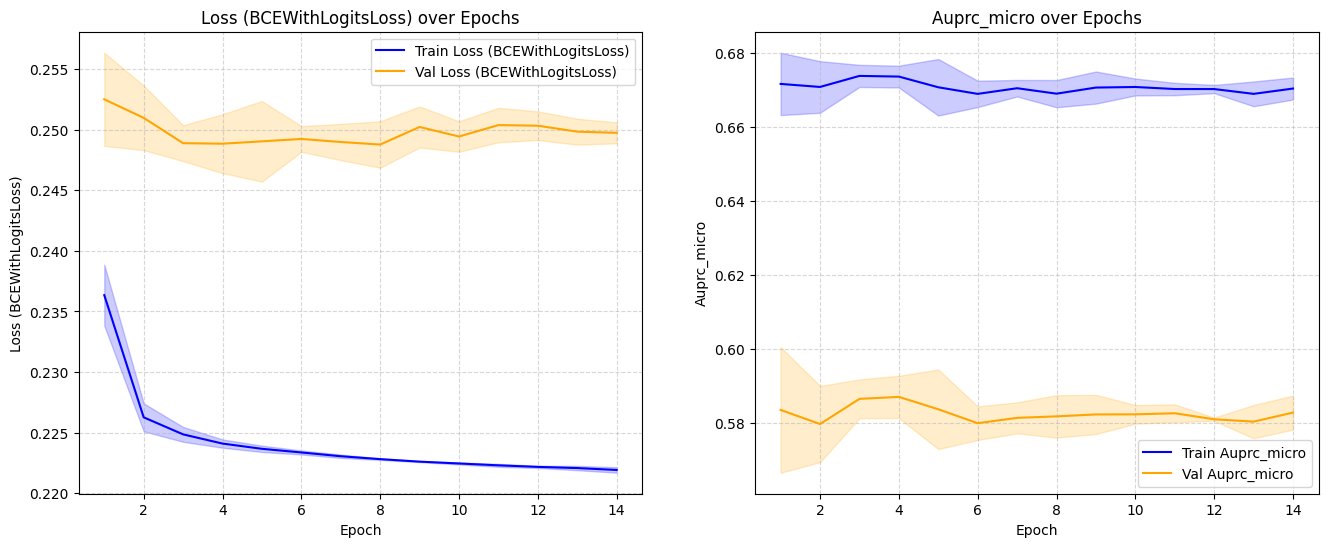

In [16]:
hgt_model = HGTModel(
    data=data,
    col_stats_dict=col_stats_dict,
    in_channels=in_channels,
    gnn_config=config["gnn_heads"]["hgt"],
    mlp_config=mlp_config,
    task_type=task_type,
    dropout=dropout
).to(device)

criterion = torch.nn.BCEWithLogitsLoss()
optimizer = torch.optim.AdamW(hgt_model.parameters(), lr=learning_rate)

trainer = Trainer(
    task=task,
    model=hgt_model,
    optimizer=optimizer,
    criterion=criterion,
    device=device
)

trainer.run_experiment(
    loader_dict,
    num_epochs,
    tune_metric="auprc_micro",
    higher_is_better=True,
    patience=10,
    print_every=3,
    num_runs=num_runs
)

# torch.save(best_weights, os.path.join(cache_dir, dataset_name, f"{hgt_model.gnn_name}_{task_name}_best_weights.pt"))

del hgt_model, optimizer, trainer
torch.cuda.empty_cache()
gc.collect()